In [1]:
import sys
print(sys.executable)  # sanity check: which Python is this?

# CPU-only (works everywhere)
%pip install torch --index-url https://download.pytorch.org/whl/cpu

# OR, if you want CUDA 12.1 (and you have a compatible NVIDIA setup)
# %pip install torch --index-url https://download.pytorch.org/whl/cu121


c:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\.venv\Scripts\python.exe
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install seaborn
# if you have multiple Pythons:


In [3]:
# Minimal needed for your project files that import torch/numpy/scipy/sklearn
%pip install numpy scipy scikit-learn pandas matplotlib

# If you also need PyTorch in this kernel:
# CPU-only wheel (works everywhere)
%pip install torch --index-url https://download.pytorch.org/whl/cpu
# GPU (only if you have a compatible NVIDIA setup):
# %pip install torch --index-url https://download.pytorch.org/whl/cu121


Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install numpy


Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE
import time
import SoftImpute
import TabCSDI


In [6]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from SoftImpute import softimpute, cv_softimpute
from TabCSDI import TabCSDIImputer


In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time


In [8]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [9]:
data = fetch_openml(name="wine", version=2, as_frame=True)
X_full = data.data.copy()

In [10]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malic_acid                    178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  OD280/OD315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
dtypes: fl

Scalling the data to min-max scale

In [13]:
#scaler = MinMaxScaler() #data [0,1] #giving better result
#X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

scaler = StandardScaler()
X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [14]:
GroundTruth = X_full.copy()
X = X_full.copy()
print(GroundTruth)

      Alcohol  Malic_acid       Ash  Alcalinity_of_ash  Magnesium  \
0    1.518613   -0.562250  0.232053          -1.169593   1.913905   
1    0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2    0.196879    0.021231  1.109334          -0.268738   0.088358   
3    1.691550   -0.346811  0.487926          -0.809251   0.930918   
4    0.295700    0.227694  1.840403           0.451946   1.281985   
..        ...         ...       ...                ...        ...   
173  0.876275    2.974543  0.305159           0.301803  -0.332922   
174  0.493343    1.412609  0.414820           1.052516   0.158572   
175  0.332758    1.744744 -0.389355           0.151661   1.422412   
176  0.209232    0.227694  0.012732           0.151661   1.422412   
177  1.395086    1.583165  1.365208           1.502943  -0.262708   

     Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0         0.808997    1.034819             -0.659563         1.224884   
1         0.568648    0.7

Converting GroundTruth to tensor

In [15]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [16]:
GroundTruth.nunique()

Alcohol                         126
Malic_acid                      133
Ash                              79
Alcalinity_of_ash                63
Magnesium                        53
Total_phenols                    97
Flavanoids                      132
Nonflavanoid_phenols             39
Proanthocyanins                 101
Color_intensity                 132
Hue                              78
OD280/OD315_of_diluted_wines    122
Proline                         121
dtype: int64

In [17]:
print("Alcohol",GroundTruth['Alcohol'].unique())
print("Malic_acid",GroundTruth['Malic_acid'].unique())
print("Ash",GroundTruth['Ash'].unique())
print("Alcalinity_of_ash",GroundTruth['Alcalinity_of_ash'].unique())
print("Magnesium",GroundTruth["Magnesium"].unique())
print("Total_phenols",GroundTruth['Total_phenols'].unique())
print("Flavanoids",GroundTruth['Flavanoids'].unique())
print("Nonflavanoid_phenols",GroundTruth['Nonflavanoid_phenols'].unique())
print("Proanthocyanins",GroundTruth['Proanthocyanins'].unique())
print("Color_intensity",GroundTruth['Color_intensity'].unique())
print("Hue",GroundTruth['Hue'].unique())
print("OD280/OD315_of_diluted_wines",GroundTruth['OD280/OD315_of_diluted_wines'].unique())
print("Proline",GroundTruth['Proline'].unique())

Alcohol [ 1.51861254  0.24628963  0.19687903  1.69154964  0.29570023  1.48155459
  1.71625494  1.3086175   2.25977152  1.0615645   1.3580281   1.38273339
  0.92568536  2.16095032  1.70390229  0.77745356  1.60508109  1.02450655
  1.46920194  0.78980621 -0.08723191  0.87627476 -0.18605311  0.61686912
  0.06099988  0.48098997  0.36981612  1.07391715  1.2592069   0.90098006
  0.71569031  0.83921681  0.93803801  0.62922177  0.59216382  0.34511082
  0.08570518  1.50625989  0.69098501  0.50569527  1.0862698   1.49390724
  1.1109751   1.1603857   1.01215391  0.95039066  0.91333271  0.35746347
  0.88862741 -0.77898029 -0.82839089 -0.44545875  0.82686416 -1.02603329
  0.13511578  0.41922672 -0.97662269 -0.87780149  0.60451647 -0.01311602
 -1.28543893 -1.65601842  0.03629458 -1.43367073 -0.37134286 -1.23602833
 -0.34663756 -1.13720713 -0.4084008  -1.03838594 -1.66837107 -1.68072372
 -0.38369551 -1.70542902 -0.6554538  -1.47072867 -0.49486935 -0.81603824
 -1.45837602 -0.6060432  -0.71721705 -0.927

Dependecies for MAR & MNAR

In [18]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
mean_flavanoids = GroundTruth["Flavanoids"].mean()
median_nonflavanoid = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()


dependencies_mar = {
    "Malic_acid": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Ash": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Alcalinity_of_ash": {
        "influencers": ["Ash"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] > mean_ash else 0.1
    },
    "Magnesium": {
        "influencers": ["Total_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] < median_phenols else 0.1
    },
    "Total_phenols": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "Flavanoids": {
        "influencers": ["Malic_acid"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] < median_malic else 0.1
    },
    "Nonflavanoid_phenols": {
        "influencers": ["Flavanoids"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] > mean_flavanoids else 0.1
    },
    "Proanthocyanins": {
        "influencers": ["Nonflavanoid_phenols"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] < median_nonflavanoid else 0.1
    },
    "Color_intensity": {
        "influencers": ["Alcohol"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] > mean_alcohol else 0.1
    },
    "Hue": {
        "influencers": ["Color_intensity"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] > median_color else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "influencers": ["Hue"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] < median_color else 0.1
    },
    "Proline": {
        "influencers": ["OD280/OD315_of_diluted_wines"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] > median_od280 else 0.1
    },
    "Alcohol": {
        "influencers": ["Proline"],  # Adding this as MAR (if you're okay with it having missingness)
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] > mean_proline else 0.1
    }
}



In [19]:
mean_alcohol = GroundTruth["Alcohol"].mean()
median_malic = GroundTruth["Malic_acid"].median()
mean_ash = GroundTruth["Ash"].mean()
median_alcalinity = GroundTruth["Alcalinity_of_ash"].median()
mean_magnesium = GroundTruth["Magnesium"].mean()
median_phenols = GroundTruth["Total_phenols"].median()
median_flav = GroundTruth["Flavanoids"].median()
median_nonflav = GroundTruth["Nonflavanoid_phenols"].median()
mean_proanthocyanins = GroundTruth["Proanthocyanins"].mean()
median_color = GroundTruth["Color_intensity"].median()
mean_hue = GroundTruth["Hue"].mean()
median_od280 = GroundTruth["OD280/OD315_of_diluted_wines"].median()
mean_proline = GroundTruth["Proline"].mean()

dependencies_mnar = {
    "Alcohol": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcohol"] < mean_alcohol else 0.1
    },
    "Malic_acid": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Malic_acid"] == median_malic else 0.1
    },
    "Ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Ash"] >= mean_ash else 0.1
    },
    "Alcalinity_of_ash": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Alcalinity_of_ash"] <= median_alcalinity else 0.1
    },
    "Magnesium": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Magnesium"] >= mean_magnesium else 0.1
    },
    "Total_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Total_phenols"] <= median_phenols else 0.1
    },
    "Flavanoids": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Flavanoids"] == median_flav else 0.1
    },
    "Nonflavanoid_phenols": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Nonflavanoid_phenols"] <= median_nonflav else 0.1
    },
    "Proanthocyanins": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proanthocyanins"] < mean_proanthocyanins else 0.1
    },
    "Color_intensity": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Color_intensity"] <= median_color else 0.1
    },
    "Hue": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Hue"] >= mean_hue else 0.1
    },
    "OD280/OD315_of_diluted_wines": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["OD280/OD315_of_diluted_wines"] >= median_od280 else 0.1
    },
    "Proline": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Proline"] <= mean_proline else 0.1
    }
}


## MCAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [20]:

missing_rates = [10,30,50,70,90]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mcar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 300, batchsize=64)

        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mcar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })


    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=20)

    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=2500, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2500)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mcar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2,# keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mcar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm":"TabCSDI",
            "MissingRate":missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm":"TabCSDI",
        "MissingRate":missing_rate,
        "Run":"mean",
        "MAE":tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_tab[missing_mask.values].flatten(),
                    imputed_std_tab[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm":"TabCSDI","MissingRate":missing_rate,"Time":total_time_sec,
            "TrueValue":t,"ImputedMean":m,"ImputedStd":s
        })
        
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2,# keep is_linear=False to avoid extra deps
        )
    tabS.fit(miss_mcar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_tabS[missing_mask.values]
        )
    result_mae.append({
        "Algorithm":"TabCSDI-S",
        "MissingRate":missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_tabS[missing_mask.values].flatten(),
                        std_tabS[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm":"TabCSDI-S","MissingRate":missing_rate,"Time":total_time_sec,
                "TrueValue":t,"ImputedMean":m,"ImputedStd":s
            })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv", index=False)


10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/500] loss=0.989184
[  50/500] loss=0.452070
[ 100/500] loss=0.525836
[ 150/500] loss=0.385933
[ 200/500] loss=0.441852
[ 250/500] loss=0.402547
[ 300/500] loss=0.383675
[ 350/500] loss=0.330541
[ 400/500] loss=0.326109
[ 450/500] loss=0.350770
[ 500/500] loss=0.379191
Run 2...
[   1/500] loss=0.964787
[  50/500] loss=0.420043
[ 100/500] loss=0.448199
[ 150/500] loss=0.428749
[ 200/500] loss=0.379605
[ 250/500] loss=0.452717
[ 300/500] loss=0.447875
[ 350/500] loss=0.380553
[ 400/500] loss=0.335075
[ 450/500] loss=0.421894
[ 500/500] loss=0.334251
Run 3...
[   1/500] loss=0.985482
[  50/500] loss=0.430758
[ 100/500] loss=0.390065
[ 150/500] loss=0.389053
[ 200/500] loss=0.38

Multiple runs comparision

In [21]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mcar = Inject_Missing_Values()
    miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
    missing_mask = miss_mcar.isna()
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    X_missing = miss_mcar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=300, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=2500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mcar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2,# keep is_linear=False to avoid extra deps
        )
                imputed = imputer.fit_transform(miss_mcar.to_numpy()) 
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...
[   1/500] loss=1.020033
[  50/500] loss=0.452857
[ 100/500] loss=0.482030
[ 150/500] loss=0.422266
[ 200/500] loss=0.420511
[ 250/500] loss=0.443198
[ 300/500] loss=0.408469
[ 350/500] loss=0.304948
[ 400/500] loss=0.440922
[ 450/500] loss=0.391828
[ 500/500] loss=0.379303
Run 2...
[   1/500] loss=1.012832
[  50/500] 

Multiple Sample Run

In [22]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mcar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
       
    missing_mask = miss_mcar.isna()
   
   
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mcar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=2500, batch_size=512)
            X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
            tabS.fit(miss_mcar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=sample)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_sample_runs.csv", index=False)

30
10
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.954087
[  50/500] loss=0.446576
[ 100/500] loss=0.355721
[ 150/500] loss=0.468768
[ 200/500] loss=0.387149
[ 250/500] loss=0.367926
[ 300/500] loss=0.417594
[ 350/500] loss=0.415236
[ 400/500] loss=0.409423
[ 450/500] loss=0.363686
[ 500/500] loss=0.385211
30
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=1.010405
[  50/500] loss=0.402395
[ 100/500] loss=0.435200
[ 150/500] loss=0.432962
[ 200/500] loss=0.424429
[ 250/500] loss=0.381187
[ 300/500] loss=0.341587
[ 350/500] loss=0.318731
[ 400/500] loss=0.345334
[ 450/500] loss=0.329542
[ 500/500] loss=0.396341
50
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.995881
[  50/500] loss=0.422803
[ 100/500] loss=0.449544
[ 150/500] loss=0.442901
[ 200/500] loss=0.451366
[ 250/500] loss=0.467366
[ 300/500] loss=0.359999
[ 350/500] loss=0.358479
[ 400/500] loss=0.429542
[ 450/500] loss=0.329968
[ 500/500] loss=0.341619
70
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=1.038323
[  50/500] loss=0.373032
[ 100/500]

In [23]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mcar = []
runs=1


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
       
    missing_mask = miss_mcar.isna()
   
   
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
            
            t_method_start = time.perf_counter()
            miwae = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mcar, return_std=True, inference_K=sample)
            total_time_sec = time.perf_counter() - t_method_start

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "time": total_time_sec,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
            t_method_start = time.perf_counter()
            imputer_gain = GAINImputer(epochs=2500, batch_size=512)
            X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            total_time_sec = time.perf_counter() - t_method_start
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "time":total_time_sec,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
            t_method_start = time.perf_counter()
            tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
            tabS.fit(miss_mcar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=sample)
            total_time_sec = time.perf_counter() - t_method_start
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "time":total_time_sec ,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_sample_runs_time.csv", index=False)

30
10
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.936502
[  50/500] loss=0.497732
[ 100/500] loss=0.361315
[ 150/500] loss=0.378611
[ 200/500] loss=0.357676
[ 250/500] loss=0.461311
[ 300/500] loss=0.392177
[ 350/500] loss=0.310675
[ 400/500] loss=0.389312
[ 450/500] loss=0.343343
[ 500/500] loss=0.413251
30
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.974851
[  50/500] loss=0.512886
[ 100/500] loss=0.511935
[ 150/500] loss=0.494537
[ 200/500] loss=0.495719
[ 250/500] loss=0.384291
[ 300/500] loss=0.445428
[ 350/500] loss=0.396188
[ 400/500] loss=0.328951
[ 450/500] loss=0.374467
[ 500/500] loss=0.344736
50
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=1.080440
[  50/500] loss=0.447681
[ 100/500] loss=0.415792
[ 150/500] loss=0.431586
[ 200/500] loss=0.395502
[ 250/500] loss=0.444393
[ 300/500] loss=0.337310
[ 350/500] loss=0.417361
[ 400/500] loss=0.316588
[ 450/500] loss=0.329053
[ 500/500] loss=0.327479
70
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.980492
[  50/500] loss=0.402747
[ 100/500]

In [24]:
# === Train once; for each sampling S, add the (same) training time to sampling time ===
import time, numpy as np, pandas as pd, torch

missing_rate = 30
samples = [10, 30, 50, 70, 90, 110]
repeats = 3  # median over repeats to reduce jitter

def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def median_time(fn, n=3):
    vals = []
    for _ in range(n):
        cuda_sync(); t0 = time.perf_counter()
        fn()
        cuda_sync(); vals.append(time.perf_counter() - t0)
    return float(np.median(vals))

# -----------------------------------------
# Make the 30% MCAR data once
# -----------------------------------------
gen = Inject_Missing_Values()
miss_mcar, _ = gen.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float32)
missing_mask = miss_mcar.isna()

rows = []

# ============================================================
# MIWAE-S
# ============================================================
# A) If MIWAE exposes transform_with_std (inference-only), UNCOMMENT this block and comment out the fallback.
# ---- Train once
# miwae = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
#                      hidden_dims=[64,64], K=10, epochs=2500)
# def train_once():
#     # No separate fit(), so do one training call with small K to initialize weights.
#     # If your class *does* have miwae.fit(...), use that instead.
#     miwae.fit_transform_std(miss_mcar, return_std=True, inference_K=1)
# train_time_miwae = median_time(train_once, n=repeats)
#
# # ---- For each S: inference-only time + add the same training time
# for S in samples:
#     def infer_only():
#         miwae.transform_with_std(miss_mcar, inference_K=S)
#     sample_time = median_time(infer_only, n=repeats)
#     rows.append({"Algorithm":"MIWAE-S","Sample":S,
#                  "train_time_sec":train_time_miwae,
#                  "sample_time_sec":sample_time,
#                  "total_time_sec":train_time_miwae + sample_time})

# B) Fallback (works with current API: only fit_transform_std)
#    Idea: measure ONE training time (train+K=1) → use as "train once" time.
#    For each S, estimate sampling time by (train+K=S) - (train+K=1) measured back-to-back,
#    then total(S) = train_time_once + sampling_time(S).
def train_plus_k1():
    _ = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                     hidden_dims=[64,64], K=10, epochs=2500
                    ).fit_transform_std(miss_mcar, return_std=True, inference_K=1)

# One “train once” time (we’ll add this to every S)
train_time_miwae = median_time(train_plus_k1, n=repeats)

for S in samples:
    # Pairwise measure in the same conditions to get a stable sampling delta
    def total_k1():
        _ = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                         hidden_dims=[64,64], K=10, epochs=2500
                        ).fit_transform_std(miss_mcar, return_std=True, inference_K=1)
    def total_kS():
        _ = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                         hidden_dims=[64,64], K=10, epochs=2500
                        ).fit_transform_std(miss_mcar, return_std=True, inference_K=S)

    t_k1 = median_time(total_k1, n=repeats)
    t_kS = median_time(total_kS, n=repeats)
    sample_time = max(t_kS - t_k1, 1e-6)  # estimated sampling-only
    rows.append({"Algorithm":"MIWAE-S","Sample":S,
                 "train_time_sec":train_time_miwae,
                 "sample_time_sec":sample_time,
                 "total_time_sec":train_time_miwae + sample_time})

# ============================================================
# GAIN-S  (clean: train once, then sample)
# ============================================================
gain = GAINImputer(epochs=2500, batch_size=512)

def gain_train():
    _ = gain.fit_transform(X_missing_tensor)   # training only; discard output
train_time_gain = median_time(gain_train, n=repeats)

for S in samples:
    def gain_sample():
        _ = gain.sample(num_samples=S)         # sampling only
    sample_time = median_time(gain_sample, n=repeats)
    rows.append({"Algorithm":"GAIN-S","Sample":S,
                 "train_time_sec":train_time_gain,
                 "sample_time_sec":sample_time,
                 "total_time_sec":train_time_gain + sample_time})


# -----------------------------------------
df = pd.DataFrame(rows).sort_values(["Algorithm","Sample"]).reset_index(drop=True)
df.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_time_vs_samples_train_once_total2.csv", index=False)
print(df)


   Algorithm  Sample  train_time_sec  sample_time_sec  total_time_sec
0     GAIN-S      10       15.753527         0.007633       15.761160
1     GAIN-S      30       15.753527         0.023243       15.776770
2     GAIN-S      50       15.753527         0.033504       15.787031
3     GAIN-S      70       15.753527         0.051255       15.804781
4     GAIN-S      90       15.753527         0.062511       15.816038
5     GAIN-S     110       15.753527         0.067585       15.821111
6    MIWAE-S      10       40.333133         0.000001       40.333134
7    MIWAE-S      30       40.333133         0.000001       40.333134
8    MIWAE-S      50       40.333133         0.000001       40.333134
9    MIWAE-S      70       40.333133         3.220666       43.553799
10   MIWAE-S      90       40.333133         2.472464       42.805597
11   MIWAE-S     110       40.333133         1.721449       42.054582


In [25]:
# === Time vs Samples (Train once + sampling-only) for MIWAE-S, GAIN-S, TabCSDI-S ===
# Notes:
# - Uses 30% MCAR split once.
# - For each method: measure train-once time (median of repeats on fresh instances),
#   then measure sampling-only time on a separately trained instance.
# - Results saved to CSV with columns: Algorithm, Sample, train_time_sec, sample_time_sec, total_time_sec.

import time, gc, numpy as np, pandas as pd, torch
# Assumed available in your environment:
# from your_module import Inject_Missing_Values, MIWAEImputer, GAINImputer, TabCSDIImputer

# -----------------------------
# Config
# -----------------------------
missing_rate = 30
samples = [10, 30, 50, 70, 90, 110]
repeats = 3  # median over repeats to reduce jitter
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_time_sample.csv"

# -----------------------------
# Helpers
# -----------------------------
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def median_time(fn, n=3):
    vals = []
    for _ in range(n):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        cuda_sync(); t0 = time.perf_counter()
        fn()
        cuda_sync(); vals.append(time.perf_counter() - t0)
    return float(np.median(vals))

# -----------------------------
# Make the 30% MCAR data once
# -----------------------------
gen = Inject_Missing_Values()
miss_mcar, _ = gen.MCAR(X, missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float32)
missing_mask = miss_mcar.isna()

rows = []

# ============================================================
# MIWAE-S
# ============================================================
# Fallback approach for APIs exposing only fit_transform_std:
# - Measure "train + inference_K=1" as train_once proxy
# - For each S, estimate sample-only time via paired runs:
#     sample_time(S) = time(train+K=S) - time(train+K=1)
# - Total(S) = train_once_time + sample_time(S)

def miwae_train_plus_k1():
    _ = MIWAEImputer(
        input_dim=miss_mcar.shape[1],
        latent_dim=10,
        hidden_dims=[64, 64],
        K=10,
        epochs=2500
    ).fit_transform_std(miss_mcar, return_std=True, inference_K=1)

train_time_miwae = median_time(miwae_train_plus_k1, n=repeats)

for S in samples:
    def total_k1():
        _ = MIWAEImputer(
            input_dim=miss_mcar.shape[1],
            latent_dim=10,
            hidden_dims=[64, 64],
            K=10,
            epochs=2500
        ).fit_transform_std(miss_mcar, return_std=True, inference_K=1)

    def total_kS():
        _ = MIWAEImputer(
            input_dim=miss_mcar.shape[1],
            latent_dim=10,
            hidden_dims=[64, 64],
            K=10,
            epochs=2500
        ).fit_transform_std(miss_mcar, return_std=True, inference_K=S)

    t_k1 = median_time(total_k1, n=repeats)
    t_kS = median_time(total_kS, n=repeats)
    sample_time = max(t_kS - t_k1, 1e-6)

    rows.append({
        "Algorithm": "MIWAE-S",
        "Sample": S,
        "train_time_sec": train_time_miwae,
        "sample_time_sec": sample_time,
        "total_time_sec": train_time_miwae + sample_time
    })

# ============================================================
# GAIN-S  (clean: train once, then sample)
# ============================================================
gain = GAINImputer(epochs=2500, batch_size=512)

def gain_train():
    _ = gain.fit_transform(X_missing_tensor)   # training; discard output

train_time_gain = median_time(gain_train, n=repeats)

# Ensure we have a trained model instance for sampling-only
gain_trained = GAINImputer(epochs=2500, batch_size=512)
_ = gain_trained.fit_transform(X_missing_tensor)

for S in samples:
    def gain_sample_only():
        _ = gain_trained.sample(num_samples=S)
    sample_time = median_time(gain_sample_only, n=repeats)

    rows.append({
        "Algorithm": "GAIN-S",
        "Sample": S,
        "train_time_sec": train_time_gain,
        "sample_time_sec": sample_time,
        "total_time_sec": train_time_gain + sample_time
    })

# ============================================================
# TabCSDI-S  (train once; for each S, sample-only timing)
# ============================================================
def make_tabcsdi():
    return TabCSDIImputer(
        epochs=500,
        nsamples=1,        # train fast; sample more at inference
        num_steps=600,
        timeemb=64, featureemb=64,
        channels=32, layers=3, nheads=2
        # keep is_linear=False to avoid extra deps if your class supports it
    )

def tab_train_once():
    m = make_tabcsdi()
    m.fit(miss_mcar)

train_time_tabcsdi = median_time(tab_train_once, n=repeats)

# Train a separate instance once for inference-only sampling
tabcsdi_trained = make_tabcsdi()
tabcsdi_trained.fit(miss_mcar)

for S in samples:
    def tab_sample_only():
        _ = tabcsdi_trained.transform_with_std(miss_mcar, num_samples=S)  # (mean, std)
    sample_time = median_time(tab_sample_only, n=repeats)

    rows.append({
        "Algorithm": "TabCSDI-S",
        "Sample": S,
        "train_time_sec": train_time_tabcsdi,
        "sample_time_sec": sample_time,
        "total_time_sec": train_time_tabcsdi + sample_time
    })

# -----------------------------
# Save + show
# -----------------------------
df = pd.DataFrame(rows).sort_values(["Algorithm", "Sample"]).reset_index(drop=True)
df.to_csv(save_path, index=False)
print(df)
print(f"\nSaved to: {save_path}")


[   1/500] loss=0.965302
[  50/500] loss=0.483184
[ 100/500] loss=0.394280
[ 150/500] loss=0.421002
[ 200/500] loss=0.456995
[ 250/500] loss=0.433041
[ 300/500] loss=0.379218
[ 350/500] loss=0.347091
[ 400/500] loss=0.413570
[ 450/500] loss=0.309885
[ 500/500] loss=0.372209
[   1/500] loss=1.050357
[  50/500] loss=0.542647
[ 100/500] loss=0.426656
[ 150/500] loss=0.482294
[ 200/500] loss=0.425967
[ 250/500] loss=0.465569
[ 300/500] loss=0.430857
[ 350/500] loss=0.410240
[ 400/500] loss=0.371115
[ 450/500] loss=0.395696
[ 500/500] loss=0.300924
[   1/500] loss=1.070474
[  50/500] loss=0.466699
[ 100/500] loss=0.495246
[ 150/500] loss=0.438469
[ 200/500] loss=0.518741
[ 250/500] loss=0.418283
[ 300/500] loss=0.383433
[ 350/500] loss=0.334658
[ 400/500] loss=0.354080
[ 450/500] loss=0.421091
[ 500/500] loss=0.404408
[   1/500] loss=1.060988
[  50/500] loss=0.470129
[ 100/500] loss=0.390921
[ 150/500] loss=0.393963
[ 200/500] loss=0.410042
[ 250/500] loss=0.400498
[ 300/500] loss=0.442631


In [26]:
S_list = [1, 10, 30, 50, 70, 90, 110]
def total_time_for(S):
    def run():
        _ = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                         hidden_dims=[64,64], K=10, epochs=2500
                        ).fit_transform_std(miss_mcar, return_std=True, inference_K=S)
    return median_time(run, n=3)

# Warmup once
_ = total_time_for(1)

# Measure totals
totals = [(S, total_time_for(S)) for S in S_list]
S_arr = np.array([s for s,_ in totals], dtype=float)
t_arr = np.array([t for _,t in totals], dtype=float)

# Linear fit t ≈ a + b*S
b, a = np.polyfit(S_arr, t_arr, 1)

train_time_miwae = float(a)           # intercept ≈ train-once
per_sample = float(b)                 # slope ≈ per additional sample

for S in samples:
    sample_time = max(per_sample * (S - 1), 0.0)
    rows.append({
        "Algorithm": "MIWAE-S",
        "Sample": S,
        "train_time_sec": train_time_miwae,
        "sample_time_sec": sample_time,
        "total_time_sec": train_time_miwae + sample_time
    })


## MAR

In [27]:
missing_rates = [10,30,50,70,90]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=2500, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2500)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm":"TabCSDI",
            "MissingRate":missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm":"TabCSDI",
        "MissingRate":missing_rate,
        "Run":"mean",
        "MAE":tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_tab[missing_mask.values].flatten(),
                    imputed_std_tab[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm":"TabCSDI","MissingRate":missing_rate,"Time":total_time_sec,
            "TrueValue":t,"ImputedMean":m,"ImputedStd":s
        })
        
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
    tabS.fit(miss_mar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_tabS[missing_mask.values]
        )
    result_mae.append({
        "Algorithm":"TabCSDI-S",
        "MissingRate":missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_tabS[missing_mask.values].flatten(),
                        std_tabS[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm":"TabCSDI-S","MissingRate":missing_rate,"Time":total_time_sec,
                "TrueValue":t,"ImputedMean":m,"ImputedStd":s
            })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv", index=False)


10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/500] loss=1.043724
[  50/500] loss=0.471538
[ 100/500] loss=0.458556
[ 150/500] loss=0.423116
[ 200/500] loss=0.383217
[ 250/500] loss=0.386260
[ 300/500] loss=0.408376
[ 350/500] loss=0.389220
[ 400/500] loss=0.376183
[ 450/500] loss=0.306913
[ 500/500] loss=0.362697
Run 2...
[   1/500] loss=1.028613
[  50/500] loss=0.463272
[ 100/500] loss=0.408728
[ 150/500] loss=0.361732
[ 200/500] loss=0.336835
[ 250/500] loss=0.453032
[ 300/500] loss=0.381693
[ 350/500] loss=0.382011
[ 400/500] loss=0.317359
[ 450/500] loss=0.356754
[ 500/500] loss=0.390295
Run 3...
[   1/500] loss=1.031911
[  50/500] loss=0.454029
[ 100/500] loss=0.330780
[ 150/500] loss=0.490814
[ 200/500] loss=0.52

Multiple runs comparision

In [28]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mar = Inject_Missing_Values()
    miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
    missing_mask = miss_mar.isna()
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    X_missing = miss_mar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=300, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=2500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2# keep is_linear=False to avoid extra deps
        )
                imputed = imputer.fit_transform(miss_mar.to_numpy()) 
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...
[   1/500] loss=0.963267
[  50/500] loss=0.485509
[ 100/500] loss=0.382766
[ 150/500] loss=0.469254
[ 200/500] loss=0.418223
[ 250/500] loss=0.388380
[ 300/500] loss=0.369682
[ 350/500] loss=0.347989
[ 400/500] loss=0.425837
[ 450/500] loss=0.316316
[ 500/500] loss=0.283733
Run 2...
[   1/500] loss=1.039012
[  50/500] 

Multiple Sample Run

In [29]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
       
    missing_mask = miss_mar.isna()
   
   
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=2500, batch_size=512)
            X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
            tabS.fit(miss_mar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mar, num_samples=sample)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_sample_runs.csv", index=False)

30
10
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.947120
[  50/500] loss=0.455729
[ 100/500] loss=0.424082
[ 150/500] loss=0.440612
[ 200/500] loss=0.391197
[ 250/500] loss=0.410480
[ 300/500] loss=0.347288
[ 350/500] loss=0.341496
[ 400/500] loss=0.380496
[ 450/500] loss=0.318074
[ 500/500] loss=0.405473
30
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=1.042207
[  50/500] loss=0.406168
[ 100/500] loss=0.406774
[ 150/500] loss=0.424200
[ 200/500] loss=0.378434
[ 250/500] loss=0.418409
[ 300/500] loss=0.456192
[ 350/500] loss=0.391698
[ 400/500] loss=0.388371
[ 450/500] loss=0.379572
[ 500/500] loss=0.379555
50
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=1.054549
[  50/500] loss=0.427812
[ 100/500] loss=0.421429
[ 150/500] loss=0.313324
[ 200/500] loss=0.400923
[ 250/500] loss=0.436135
[ 300/500] loss=0.330353
[ 350/500] loss=0.401343
[ 400/500] loss=0.292284
[ 450/500] loss=0.347319
[ 500/500] loss=0.317401
70
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=1.065883
[  50/500] loss=0.477871
[ 100/500]

## MNAR

In [30]:
missing_rates = [10,30,50,70,90]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mnar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mnar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 300, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
   
    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute 
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mnar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })
    
    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_soft[missing_mask.values].flatten(),
                    imputed_std_soft[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mnar.copy()
        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time":total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })

    #GAIN
    t_method_start = time.perf_counter()
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=2500, batch_size=512)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=10, epochs=2500)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "Time":total_time_sec,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=2500, batch_size=512)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[64, 64], K=5, epochs=2500)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mnar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=2500, batch_size=512)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "Time":total_time_sec,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mnar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm":"TabCSDI",
            "MissingRate":missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm":"TabCSDI",
        "MissingRate":missing_rate,
        "Run":"mean",
        "MAE":tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_tab[missing_mask.values].flatten(),
                    imputed_std_tab[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm":"TabCSDI","MissingRate":missing_rate,"Time":total_time_sec,
            "TrueValue":t,"ImputedMean":m,"ImputedStd":s
        })
        
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
    tabS.fit(miss_mnar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mnar, num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_tabS[missing_mask.values]
        )
    result_mae.append({
        "Algorithm":"TabCSDI-S",
        "MissingRate":missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_tabS[missing_mask.values].flatten(),
                        std_tabS[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm":"TabCSDI-S","MissingRate":missing_rate,"Time":total_time_sec,
                "TrueValue":t,"ImputedMean":m,"ImputedStd":s
            })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv", index=False)


10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/500] loss=1.011654
[  50/500] loss=0.481034
[ 100/500] loss=0.436386
[ 150/500] loss=0.428580
[ 200/500] loss=0.459708
[ 250/500] loss=0.447418
[ 300/500] loss=0.370337
[ 350/500] loss=0.347529
[ 400/500] loss=0.307566
[ 450/500] loss=0.362811
[ 500/500] loss=0.383301
Run 2...
[   1/500] loss=0.992636
[  50/500] loss=0.465379
[ 100/500] loss=0.412725
[ 150/500] loss=0.392587
[ 200/500] loss=0.383622
[ 250/500] loss=0.388461
[ 300/500] loss=0.331126
[ 350/500] loss=0.338842
[ 400/500] loss=0.381129
[ 450/500] loss=0.452647
[ 500/500] loss=0.387222
Run 3...
[   1/500] loss=1.022468
[  50/500] loss=0.407024
[ 100/500] loss=0.427142
[ 150/500] loss=0.509690
[ 200/500] loss=0.49

In [31]:
result_mae

[{'Algorithm': 'OT-Impute',
  'MissingRate': 10,
  'Run': 1,
  'MAE': 0.5327926669817115},
 {'Algorithm': 'OT-Impute',
  'MissingRate': 10,
  'Run': 2,
  'MAE': 0.5209637133366786},
 {'Algorithm': 'OT-Impute',
  'MissingRate': 10,
  'Run': 3,
  'MAE': 0.5339119548005257},
 {'Algorithm': 'OT-Impute',
  'MissingRate': 10,
  'Run': 4,
  'MAE': 0.5469043058346222},
 {'Algorithm': 'OT-Impute',
  'MissingRate': 10,
  'Run': 5,
  'MAE': 0.540061041378267},
 {'Algorithm': 'OT-Impute',
  'MissingRate': 10,
  'Run': 'mean',
  'MAE': 0.5309734270794774},
 {'Algorithm': 'MICE', 'MissingRate': 10, 'Run': 1, 'MAE': 0.8188544223949275},
 {'Algorithm': 'MICE', 'MissingRate': 10, 'Run': 2, 'MAE': 0.8310158312883505},
 {'Algorithm': 'MICE', 'MissingRate': 10, 'Run': 3, 'MAE': 0.7949266019378713},
 {'Algorithm': 'MICE', 'MissingRate': 10, 'Run': 4, 'MAE': 0.8206759426058812},
 {'Algorithm': 'MICE', 'MissingRate': 10, 'Run': 5, 'MAE': 0.8119032883033471},
 {'Algorithm': 'MICE',
  'MissingRate': 10,
  'Run

Multiple runs comparision

In [32]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mnar = Inject_Missing_Values()
    miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
    missing_mask = miss_mnar.isna()
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    X_missing = miss_mnar.copy()

    algorithms = ["OT-Impute", "MICE", "SoftImpute","MIWAE", "GAIN","TabCSDI"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=300, batchsize=64)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=20, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=2500, batch_size=512)
                imputed = imputer.fit_transform(X_missing_tensor)

            elif algo == "SoftImpute":
                missng_soft = (miss_mnar.copy()).to_numpy()
                cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
                lbda = grid_lambda[np.argmin(cv_error)]
                imputed = softimpute((missng_soft), lbda)[1]

            elif algo == "TabCSDI":
                imputer = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2 # keep is_linear=False to avoid extra deps
        )
                imputed = imputer.fit_transform(miss_mnar.to_numpy()) 
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 30% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running SoftImpute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running TabCSDI for 10 runs...
Run 1...
[   1/500] loss=0.963013
[  50/500] loss=0.444714
[ 100/500] loss=0.408553
[ 150/500] loss=0.483324
[ 200/500] loss=0.412858
[ 250/500] loss=0.479394
[ 300/500] loss=0.407305
[ 350/500] loss=0.383896
[ 400/500] loss=0.316435
[ 450/500] loss=0.399583
[ 500/500] loss=0.408479
Run 2...
[   1/500] loss=0.958344
[  50/500] 

Multiple Sample Run

In [33]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,30,50,70,90,110]

# Create nested results dictionary
results_mnar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
       
    missing_mask = miss_mnar.isna()
   
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
            miwae = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                            hidden_dims=[64, 64], K=10, epochs=2500)
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mnar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
            imputer_gain = GAINImputer(epochs=2500, batch_size=512)
            X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mnar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })

            print("TabCSDI-S")
    
            tabS = TabCSDIImputer(epochs=500,
    nsamples=1,          # train fast; sample more at inference
    num_steps=600,
    timeemb=64, featureemb=64,
    channels=32, layers=3, nheads=2,# keep is_linear=False to avoid extra deps
        )
            tabS.fit(miss_mnar)
            mean_tabS, std_tabS = tabS.transform_with_std(miss_mnar, num_samples=sample)
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_tabS[missing_mask.values].flatten(),
                            std_tabS[missing_mask.values].flatten()):
                    results_mnar.append({
                        "Algorithm": "TabCSDI-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_sample_runs.csv", index=False)

30
10
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=1.041302
[  50/500] loss=0.412871
[ 100/500] loss=0.335223
[ 150/500] loss=0.460855
[ 200/500] loss=0.405109
[ 250/500] loss=0.453147
[ 300/500] loss=0.443009
[ 350/500] loss=0.372197
[ 400/500] loss=0.396679
[ 450/500] loss=0.336679
[ 500/500] loss=0.410096
30
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.989917
[  50/500] loss=0.389605
[ 100/500] loss=0.489249
[ 150/500] loss=0.444583
[ 200/500] loss=0.356904
[ 250/500] loss=0.428015
[ 300/500] loss=0.409823
[ 350/500] loss=0.300206
[ 400/500] loss=0.362648
[ 450/500] loss=0.315164
[ 500/500] loss=0.325337
50
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.880447
[  50/500] loss=0.486423
[ 100/500] loss=0.443955
[ 150/500] loss=0.473124
[ 200/500] loss=0.425740
[ 250/500] loss=0.472022
[ 300/500] loss=0.336132
[ 350/500] loss=0.422162
[ 400/500] loss=0.399975
[ 450/500] loss=0.420608
[ 500/500] loss=0.341879
70
MIWAE-S
GAIN-S
TabCSDI-S
[   1/500] loss=0.951493
[  50/500] loss=0.461501
[ 100/500]

# Visualization

## MCAR

Calibration curve for all algorithms

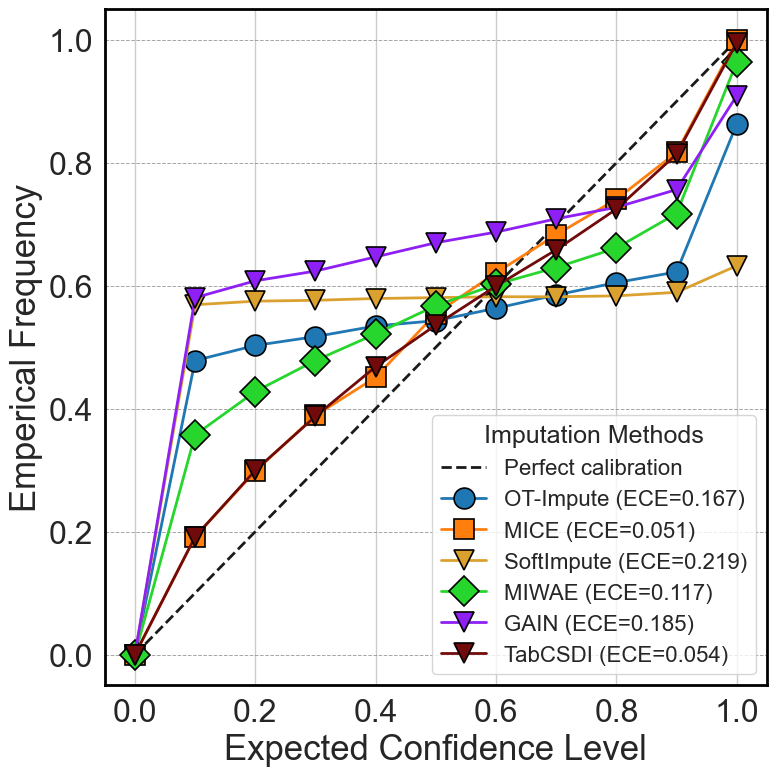

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

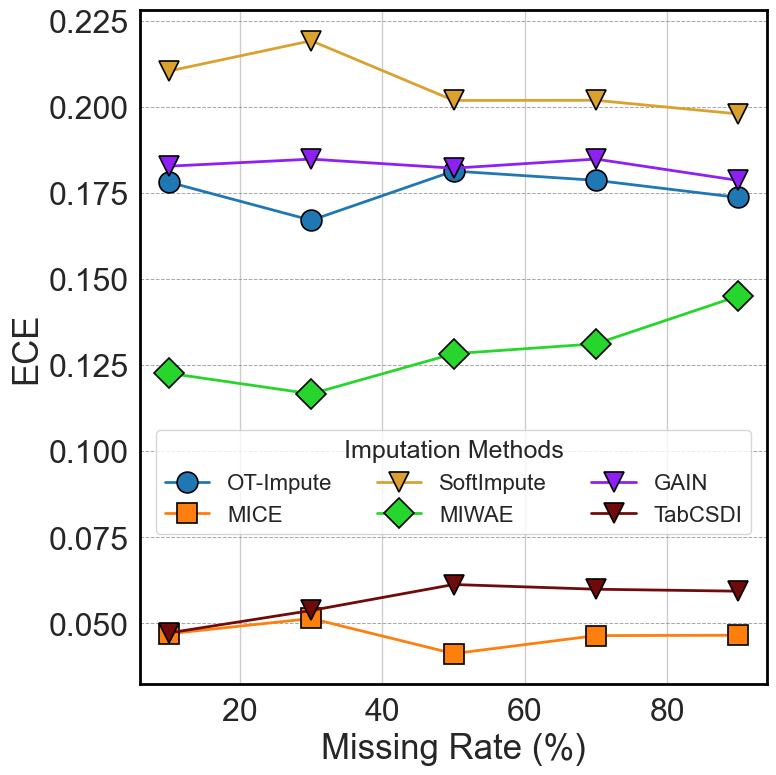

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S" or algo == "TabCSDI-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(ncol=3,title="Imputation Methods",loc='center',bbox_to_anchor=(0.5,0.3),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0.00, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MAE vs MissingRate for all algorithms

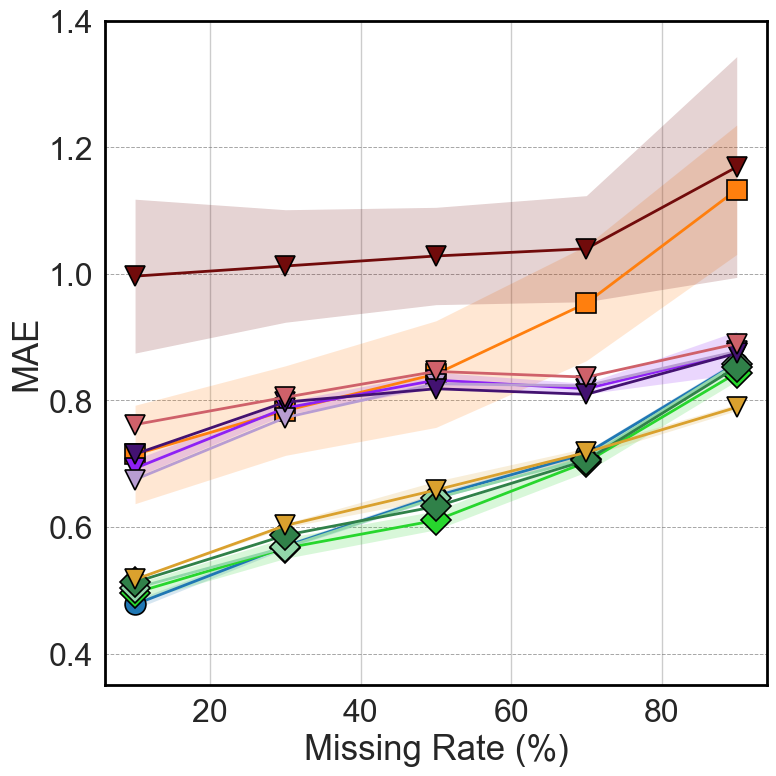

In [82]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_mae.csv"
)

x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":       {"color": "#27d62d", "marker": "D"},
    "GAIN":        {"color": "#8e20f5", "marker": "v"},
    "MIWAE-S":     {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":      {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U":     {"color": "#308149", "marker": "D"},
    "GAIN-U":      {"color": "#431271", "marker": "v"},
    "SoftImpute":  {"color": "#DAA12E", "marker": "v"},
    "TabCSDI":     {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S":   {"color": "#CF616A", "marker": "v"},
}

# Ensure expected columns exist
required_cols = {"Algorithm", "MissingRate", "MAE"}
missing_cols = required_cols - set(df_mae.columns)
if missing_cols:
    raise ValueError(f"CSV is missing expected columns: {missing_cols}")

# Sort algorithms by your desired display order (fall back to unique order in CSV)
display_order = [k for k in algo_styles.keys() if k in df_mae["Algorithm"].unique()]
for a in df_mae["Algorithm"].unique():
    if a not in display_order:
        display_order.append(a)

# === Plot ===
fig = plt.figure(figsize=(8, 8))
ax = plt.gca()

for algo in display_order:
    df_algo = df_mae[df_mae["Algorithm"] == algo].copy()
    if df_algo.empty:
        continue

    # Collect unique missing rates and compute mean/std across runs for each rate
    rates = sorted(df_algo["MissingRate"].unique())
    means, stds = [], []
    for mr in rates:
        vals = df_algo[df_algo["MissingRate"] == mr]["MAE"].astype(float).values
        means.append(np.mean(vals))
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    ax.plot(
        rates, means,
        marker=style["marker"],
        color=style["color"],
        markersize=marker_size,
        linewidth=2,
        markeredgecolor="black",
        markeredgewidth=1.2,
        label=algo
    )

    # Shaded band (mean ± std)
    lower = np.array(means) - np.array(stds)
    upper = np.array(means) + np.array(stds)
    ax.fill_between(
        rates, lower, upper,
        color=style["color"],
        alpha=0.18,
        linewidth=0
    )

# Axis labels (same variables)
ax.set_xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
ax.set_ylabel("MAE", fontsize=y_label_fontsize)

# Legend
#ax.legend(ncol=3, title="Imputation Methods", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, color='grey')

# Keep the same y-limit as requested (adjust if your values exceed this)
ax.set_ylim(0.35, 1.4)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MCAR

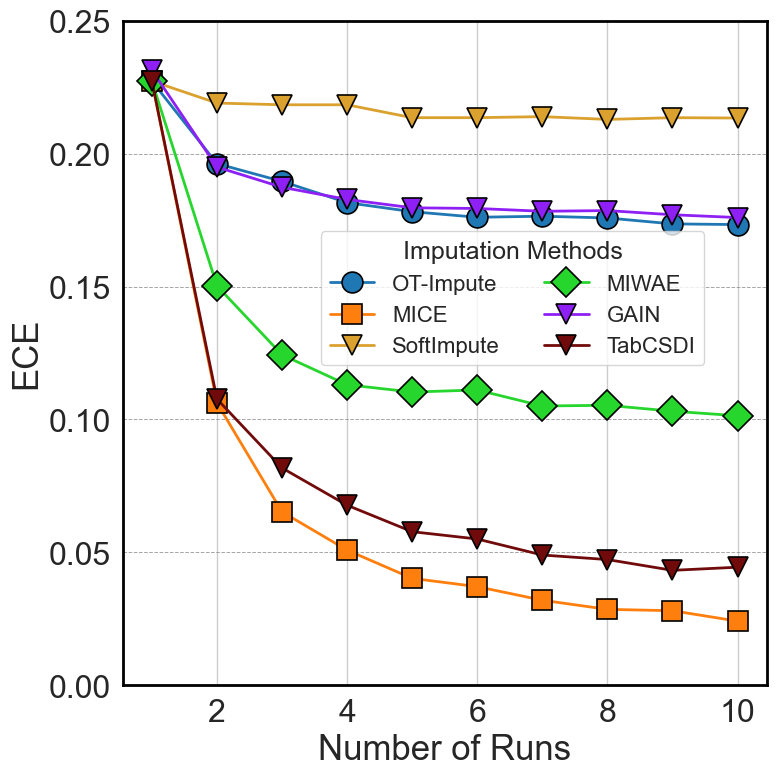

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_progressive_multiiple_run.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(ncol=2,title="Imputation Methods",loc='upper right',bbox_to_anchor=(0.92,0.70), fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MCAR ECE VS Sample 

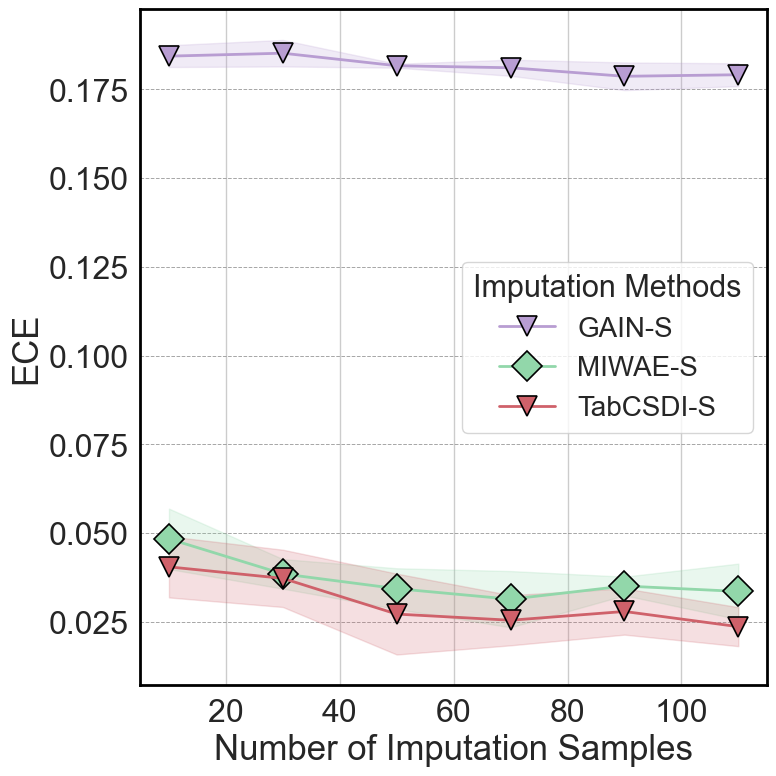

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MCAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

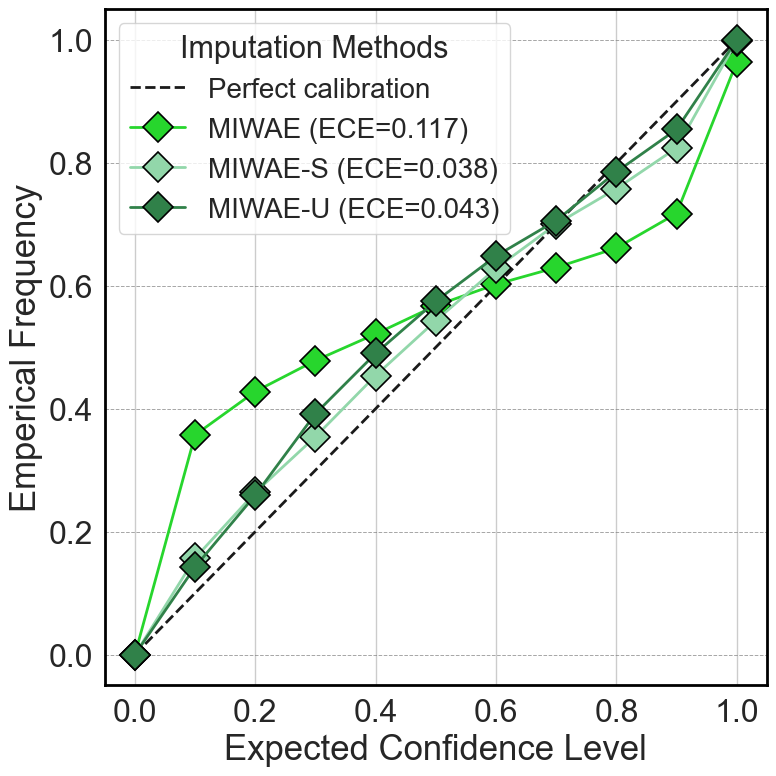

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mcar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

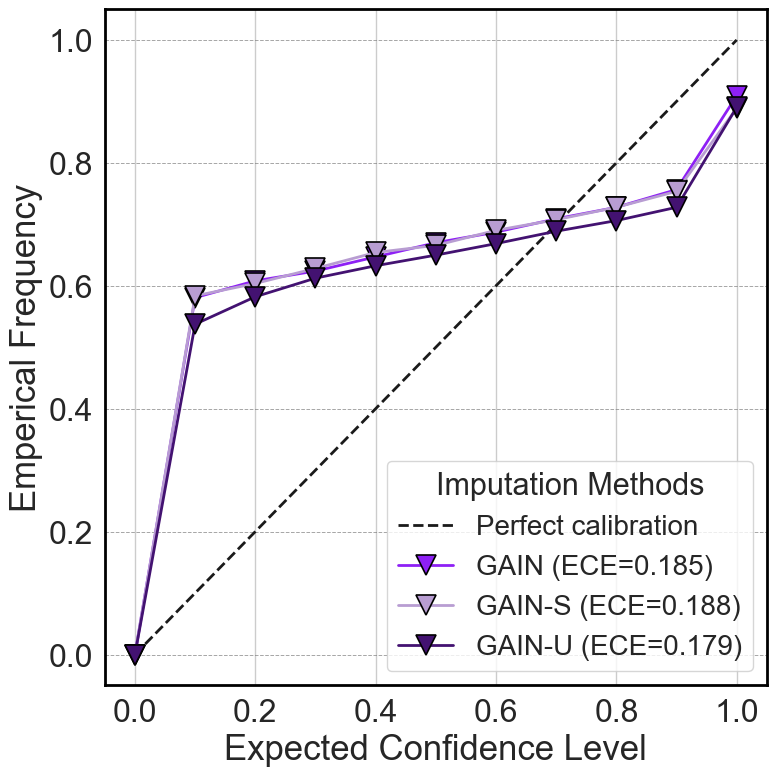

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mcar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



### TabCSDI Comparision

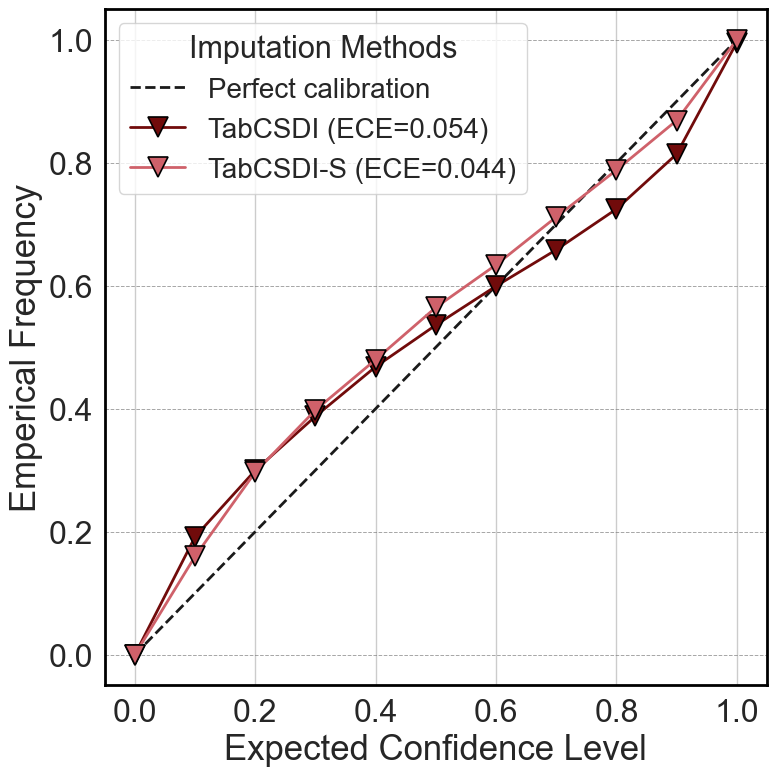

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["TabCSDI", "TabCSDI-S"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mcar_tabcsd_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


## MAR

Calibration curve for all algorithms

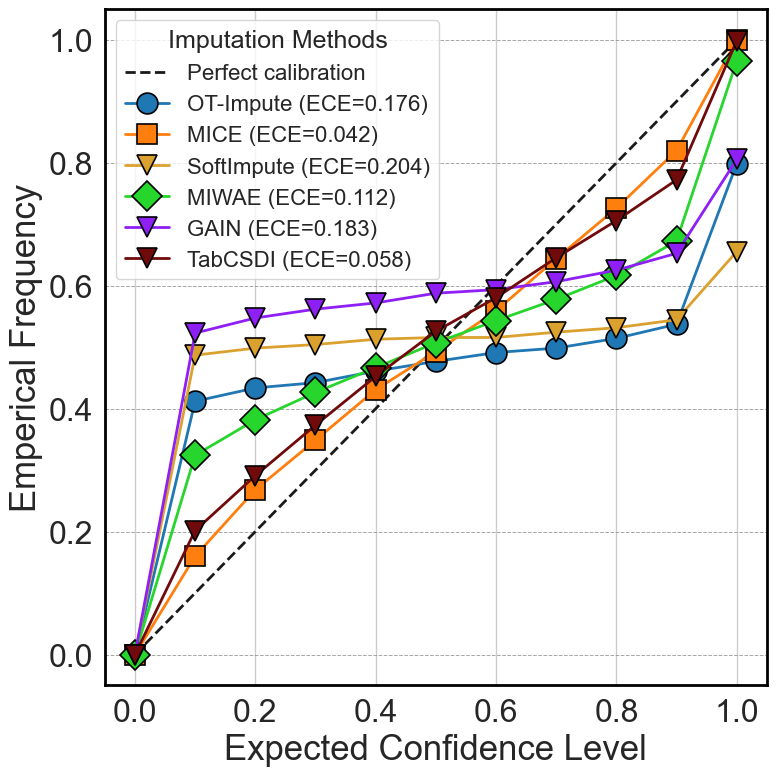

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

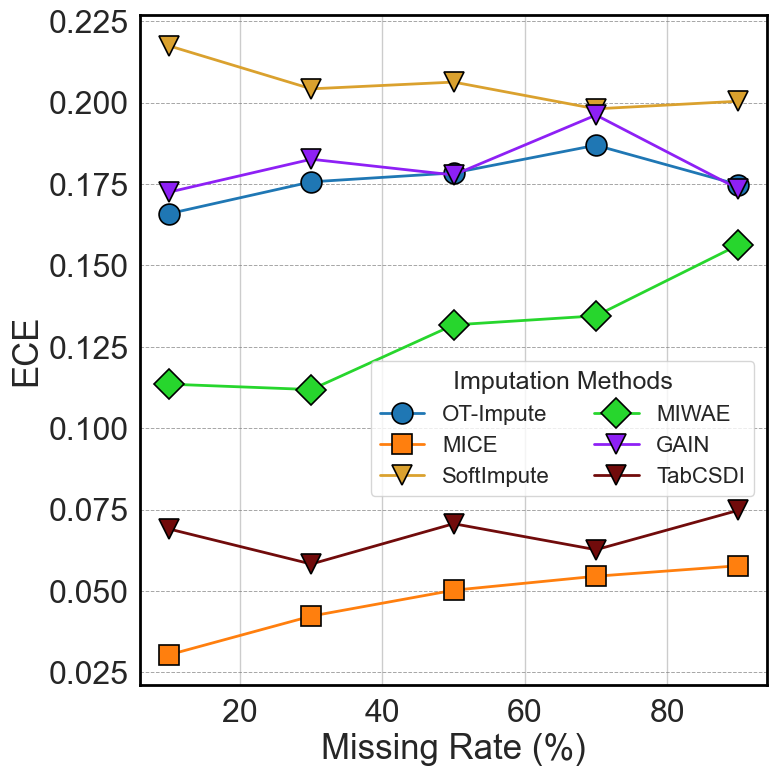

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S" or algo == "TabCSDI-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(ncol=2,title="Imputation Methods",bbox_to_anchor=(0.35,0.5) ,fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0.00, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MAE vs MissingRate for all algorithms

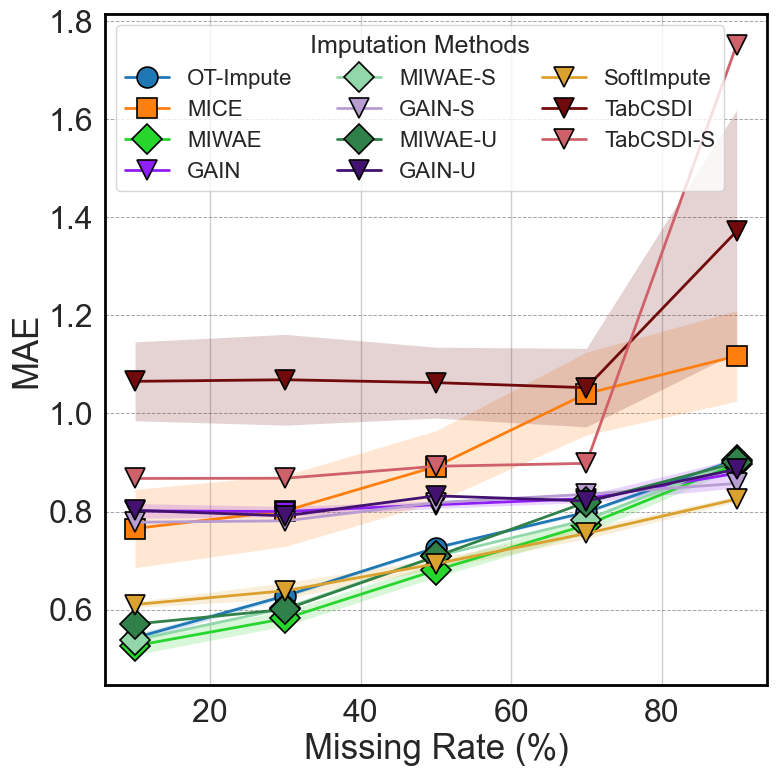

In [14]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_mae.csv"
)

x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":       {"color": "#27d62d", "marker": "D"},
    "GAIN":        {"color": "#8e20f5", "marker": "v"},
    "MIWAE-S":     {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":      {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U":     {"color": "#308149", "marker": "D"},
    "GAIN-U":      {"color": "#431271", "marker": "v"},
    "SoftImpute":  {"color": "#DAA12E", "marker": "v"},
    "TabCSDI":     {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S":   {"color": "#CF616A", "marker": "v"},
}

# Ensure expected columns exist
required_cols = {"Algorithm", "MissingRate", "MAE"}
missing_cols = required_cols - set(df_mae.columns)
if missing_cols:
    raise ValueError(f"CSV is missing expected columns: {missing_cols}")

# Sort algorithms by your desired display order (fall back to unique order in CSV)
display_order = [k for k in algo_styles.keys() if k in df_mae["Algorithm"].unique()]
for a in df_mae["Algorithm"].unique():
    if a not in display_order:
        display_order.append(a)

# === Plot ===
fig = plt.figure(figsize=(8, 8))
ax = plt.gca()

for algo in display_order:
    df_algo = df_mae[df_mae["Algorithm"] == algo].copy()
    if df_algo.empty:
        continue

    # Collect unique missing rates and compute mean/std across runs for each rate
    rates = sorted(df_algo["MissingRate"].unique())
    means, stds = [], []
    for mr in rates:
        vals = df_algo[df_algo["MissingRate"] == mr]["MAE"].astype(float).values
        means.append(np.mean(vals))
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    ax.plot(
        rates, means,
        marker=style["marker"],
        color=style["color"],
        markersize=marker_size,
        linewidth=2,
        markeredgecolor="black",
        markeredgewidth=1.2,
        label=algo
    )

    # Shaded band (mean ± std)
    lower = np.array(means) - np.array(stds)
    upper = np.array(means) + np.array(stds)
    ax.fill_between(
        rates, lower, upper,
        color=style["color"],
        alpha=0.18,
        linewidth=0
    )

# Axis labels (same variables)
ax.set_xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
ax.set_ylabel("MAE", fontsize=y_label_fontsize)

# Legend
ax.legend(ncol=3, title="Imputation Methods", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, color='grey')

# Keep the same y-limit as requested (adjust if your values exceed this)
#ax.set_ylim(0.08, 0.40)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MAR

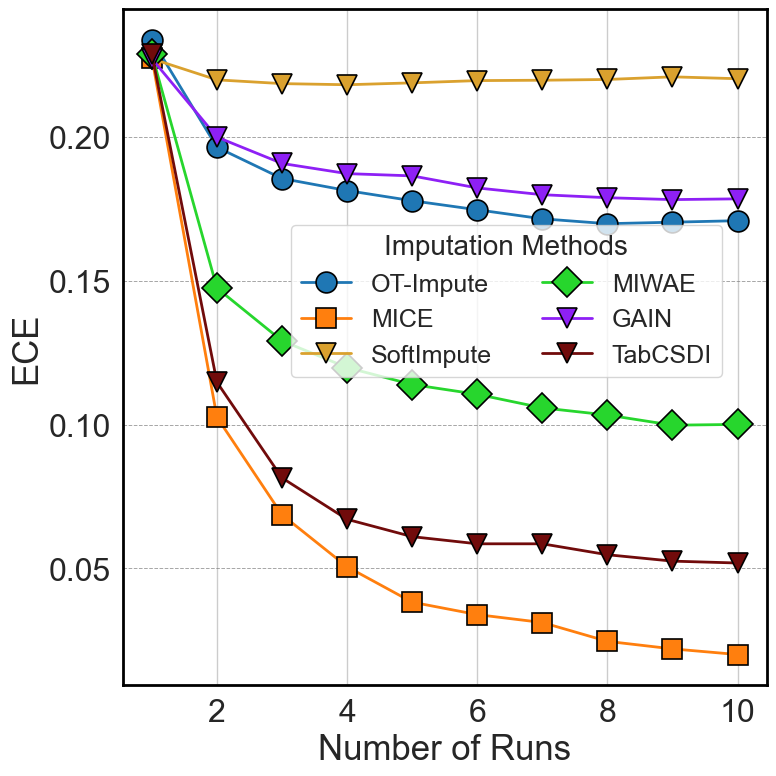

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_progressive_multiiple_run.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)
# Legend
plt.legend(ncol=2,title="Imputation Methods", loc='upper right',bbox_to_anchor=(0.95,0.7),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MAR ECE VS Sample 

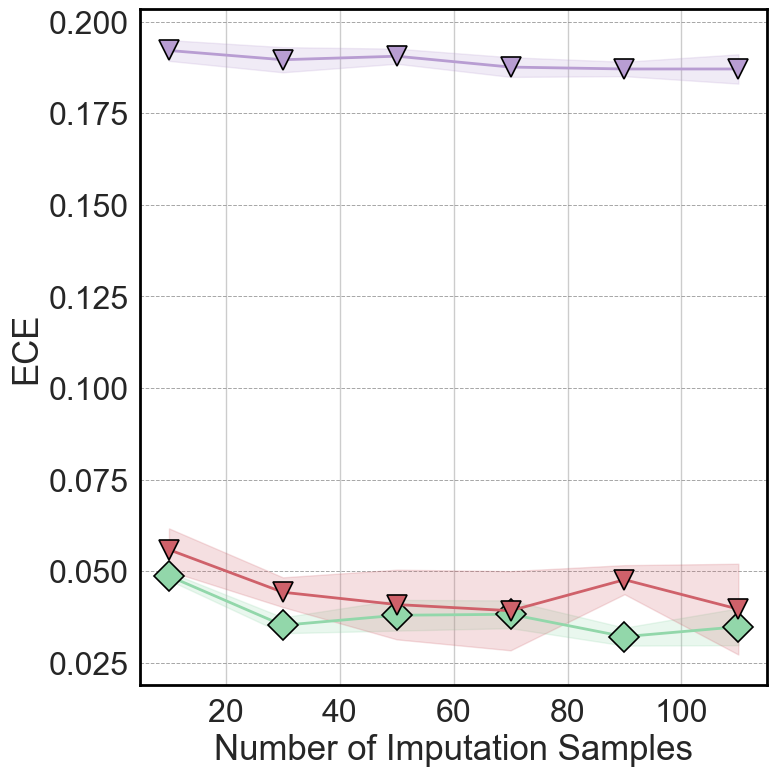

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

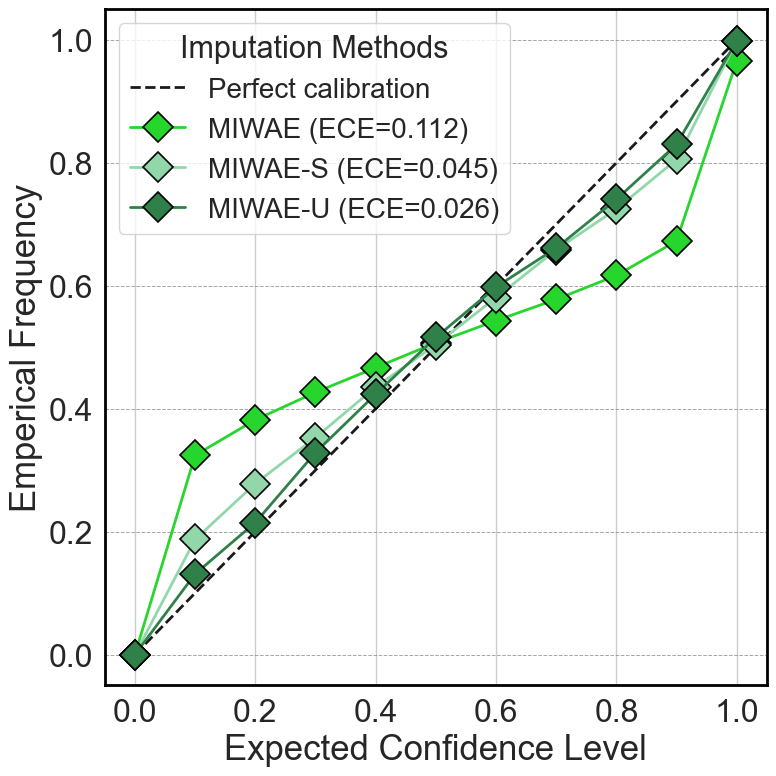

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

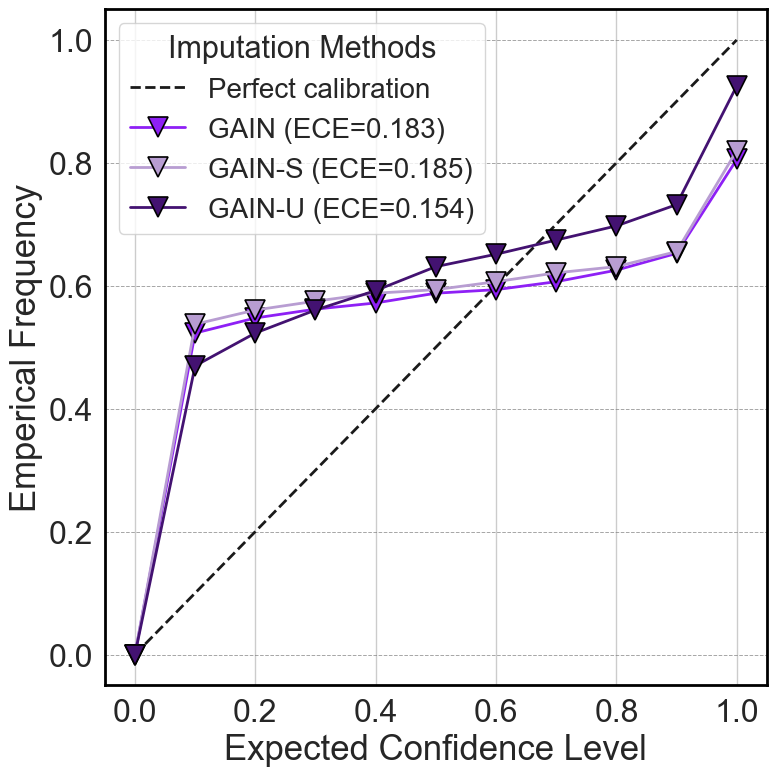

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



### TabCSDI Comparision

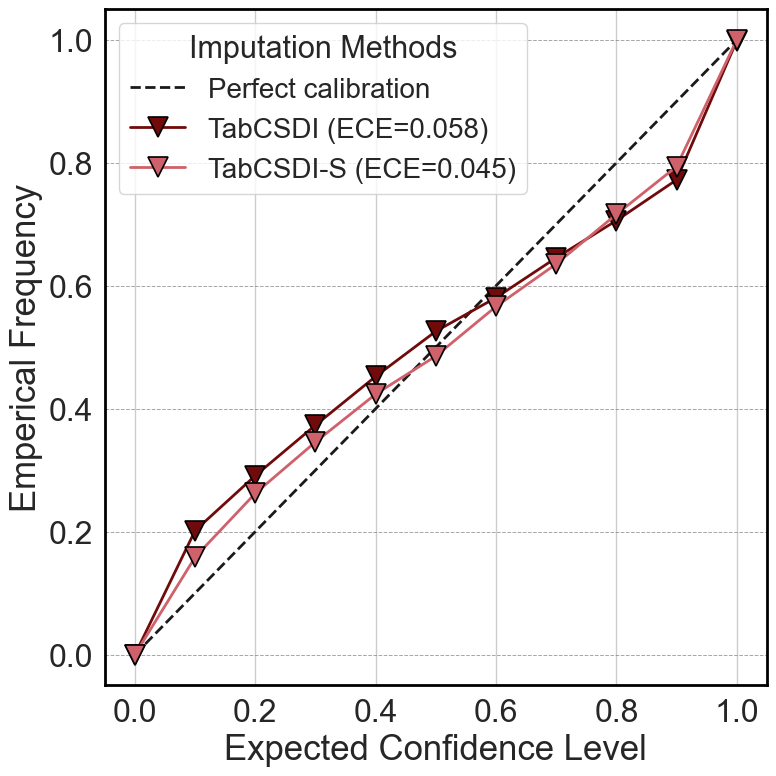

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["TabCSDI", "TabCSDI-S"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mar_tabcsd_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


## MNAR

Calibration curve for all algorithms

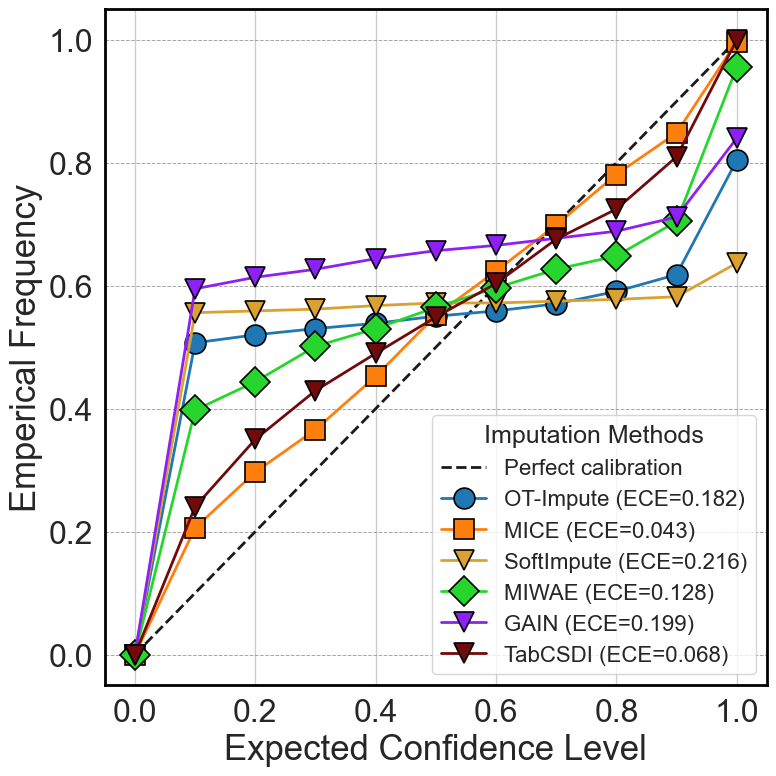

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

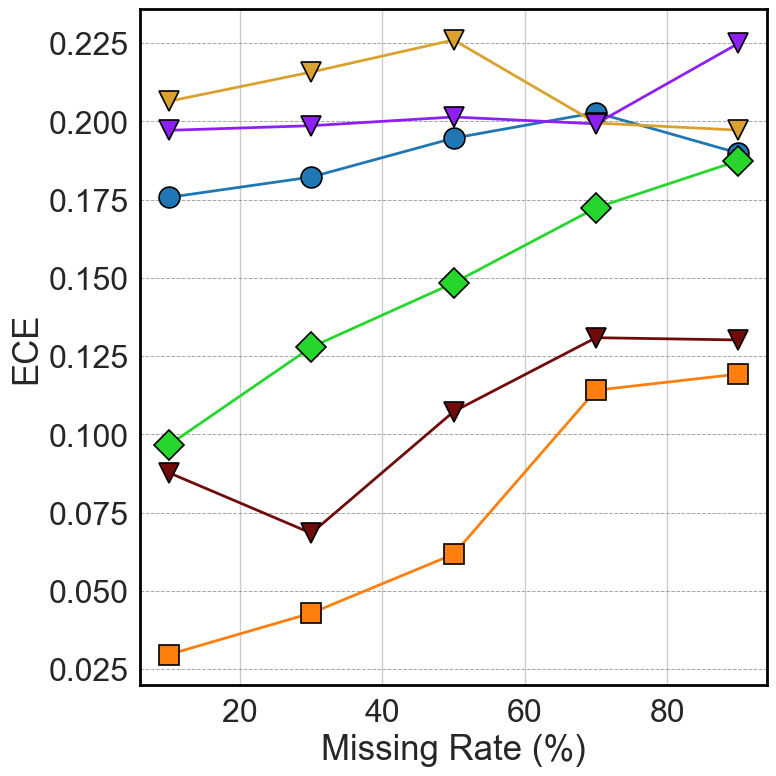

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    if algo == "MIWAE-U" or algo == "MIWAE-S" or algo == "GAIN-U" or algo == "GAIN-S" or algo == "TabCSDI-S":
        continue

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
#plt.legend(ncol=3,title="Imputation Methods",loc='center',bbox_to_anchor=(0.5,0.65),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0.00, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MAE vs MissingRate for all algorithms

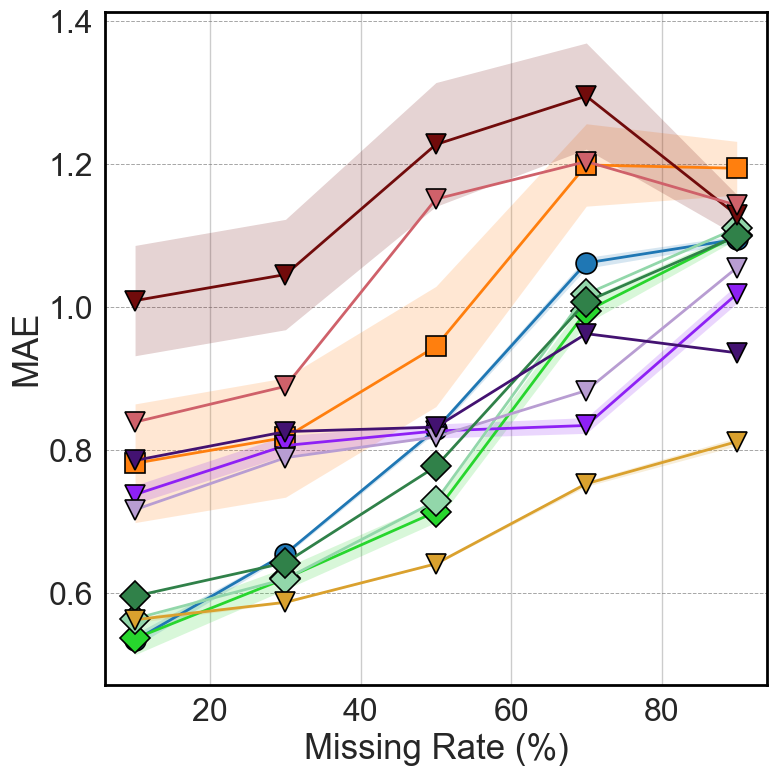

In [22]:
# === MAE vs Missing Rate (MAR) — same style/colors/sizes as your ECE plot ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Load the per-(Algorithm, MissingRate) MAE you saved
df_mae = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_mae.csv"
)

x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "MIWAE":       {"color": "#27d62d", "marker": "D"},
    "GAIN":        {"color": "#8e20f5", "marker": "v"},
    "MIWAE-S":     {"color": "#92d7aa", "marker": "D"},
    "GAIN-S":      {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U":     {"color": "#308149", "marker": "D"},
    "GAIN-U":      {"color": "#431271", "marker": "v"},
    "SoftImpute":  {"color": "#DAA12E", "marker": "v"},
    "TabCSDI":     {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S":   {"color": "#CF616A", "marker": "v"},
}

# Ensure expected columns exist
required_cols = {"Algorithm", "MissingRate", "MAE"}
missing_cols = required_cols - set(df_mae.columns)
if missing_cols:
    raise ValueError(f"CSV is missing expected columns: {missing_cols}")

# Sort algorithms by your desired display order (fall back to unique order in CSV)
display_order = [k for k in algo_styles.keys() if k in df_mae["Algorithm"].unique()]
for a in df_mae["Algorithm"].unique():
    if a not in display_order:
        display_order.append(a)

# === Plot ===
fig = plt.figure(figsize=(8, 8))
ax = plt.gca()

for algo in display_order:
    df_algo = df_mae[df_mae["Algorithm"] == algo].copy()
    if df_algo.empty:
        continue

    # Collect unique missing rates and compute mean/std across runs for each rate
    rates = sorted(df_algo["MissingRate"].unique())
    means, stds = [], []
    for mr in rates:
        vals = df_algo[df_algo["MissingRate"] == mr]["MAE"].astype(float).values
        means.append(np.mean(vals))
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    ax.plot(
        rates, means,
        marker=style["marker"],
        color=style["color"],
        markersize=marker_size,
        linewidth=2,
        markeredgecolor="black",
        markeredgewidth=1.2,
        label=algo
    )

    # Shaded band (mean ± std)
    lower = np.array(means) - np.array(stds)
    upper = np.array(means) + np.array(stds)
    ax.fill_between(
        rates, lower, upper,
        color=style["color"],
        alpha=0.18,
        linewidth=0
    )

# Axis labels (same variables)
ax.set_xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
ax.set_ylabel("MAE", fontsize=y_label_fontsize)

# Legend
#ax.legend(ncol= 3, title="Imputation Methods", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, color='grey')

# Keep the same y-limit as requested (adjust if your values exceed this)
#ax.set_ylim(0.08, 0.40)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save with same variable name pattern
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR_MAE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MNAR

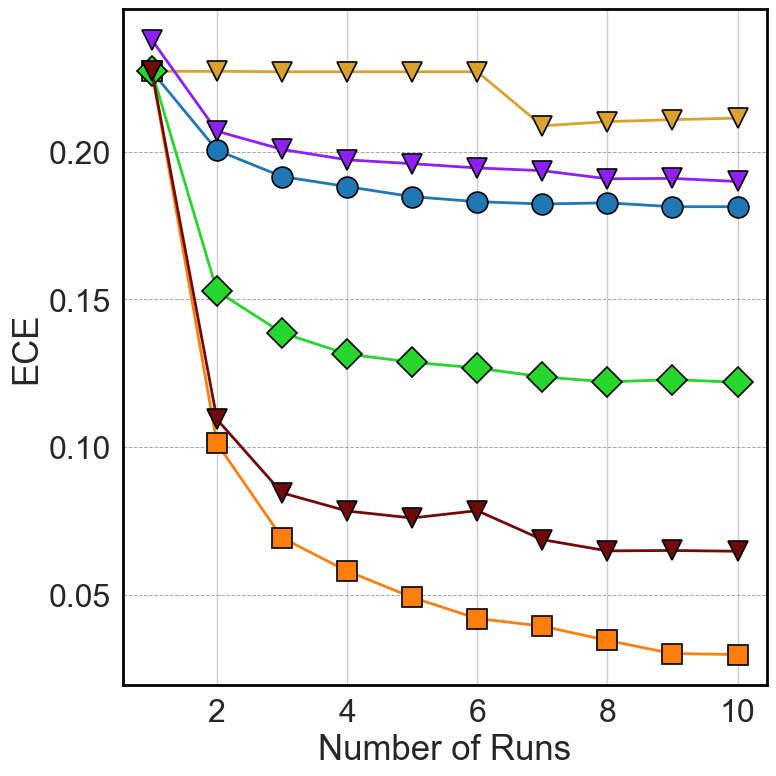

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_progressive_multiiple_run.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
#plt.legend(title="Imputation Methods", loc='upper right',bbox_to_anchor=(0.9,0.89),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.25)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MNAR ECE VS Sample 

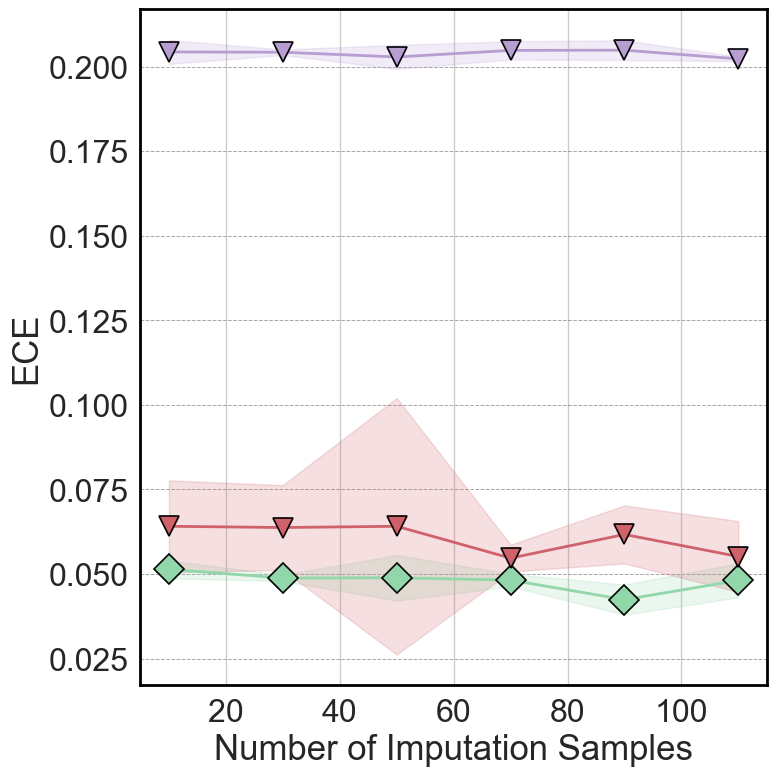

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
#plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
#ax.set_ylim(0, 0.16)
# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_MNAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

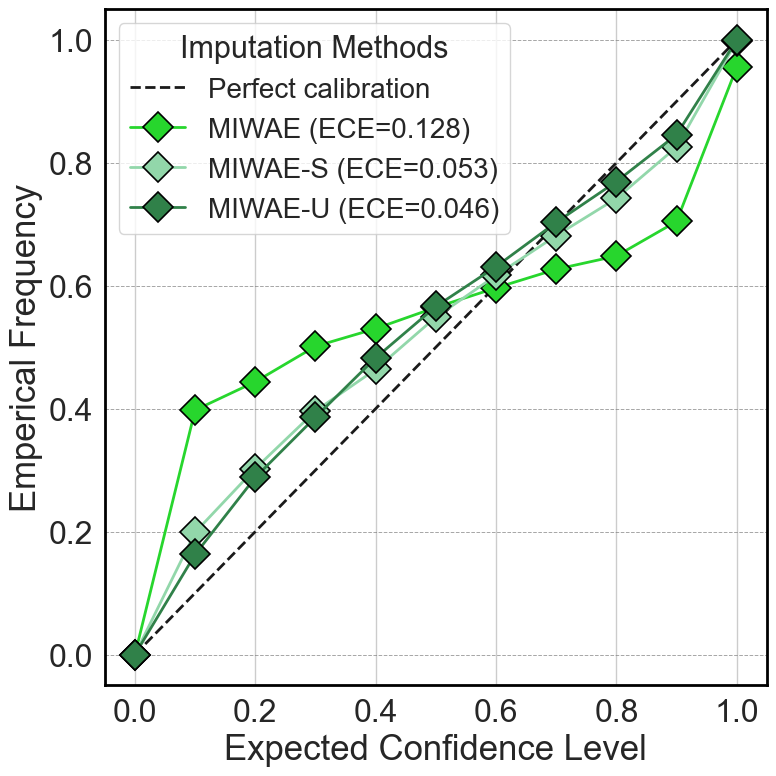

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mnar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

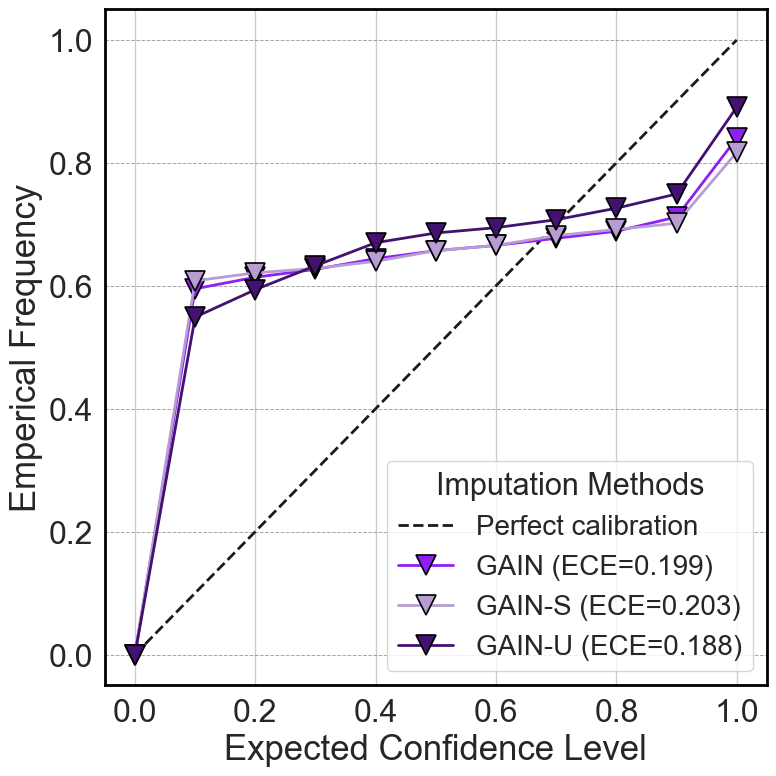

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mnar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



### TabCSDI Comparision

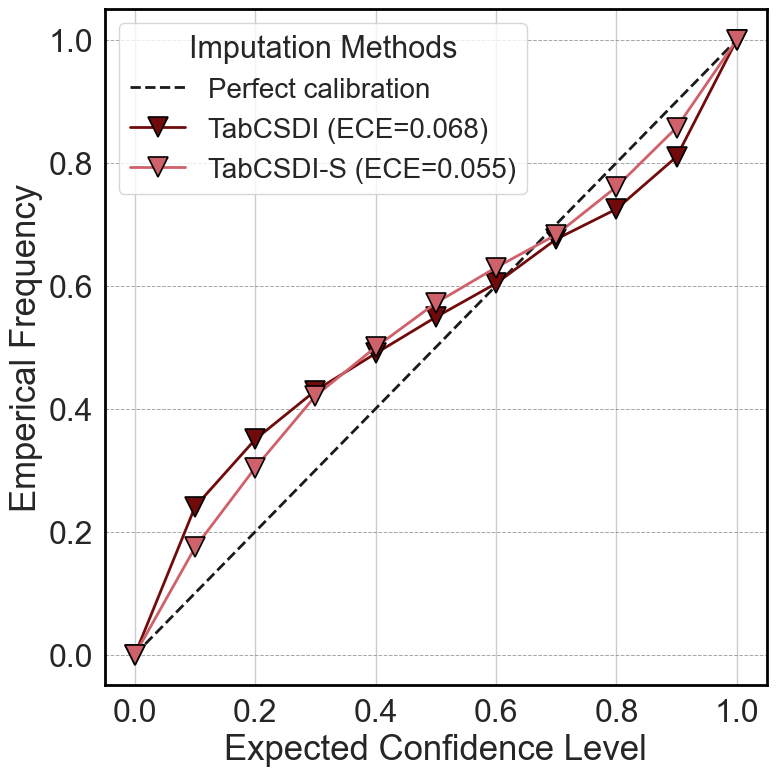

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["TabCSDI", "TabCSDI-S"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_mnar_tabcsd_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


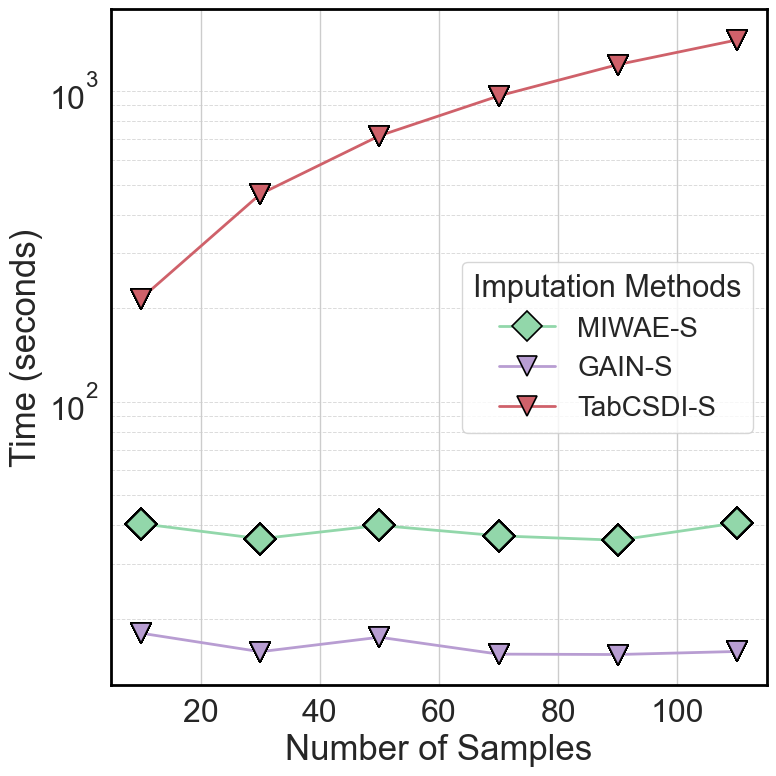

In [28]:
# The CSV only has run==1, so we'll plot for run 1 instead.
import pandas as pd
import matplotlib.pyplot as plt

path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Wine_mcar_results_sample_runs_time.csv"
df = pd.read_csv(path)

# Filter to run 1 (the only run present)
df_r1 = df[df["run"] == 1].copy()
df_r1 = df_r1[["Algorithm","Sample","time"]]

# Style
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

algo_styles = {
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

alg_order = [a for a in ["MIWAE-S", "GAIN-S", "TabCSDI-S"] if a in df_r1["Algorithm"].unique()]



# Log y
plt.figure(figsize=(8,8))
for algo in alg_order:
    sub = df_r1[df_r1["Algorithm"] == algo].sort_values("Sample")
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(sub["Sample"], sub["time"], marker=style["marker"], color=style["color"],
             markersize=marker_size, linewidth=2, markeredgecolor="black", markeredgewidth=1.2, label=algo)
plt.xlabel("Number of Samples", fontsize=x_label_fontsize)
plt.ylabel("Time (seconds)", fontsize=y_label_fontsize)
plt.yscale("log")
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color('black'); spine.set_linewidth(2)
ax.yaxis.grid(True, which="both", linestyle='--', linewidth=0.7, alpha=0.7)
plt.legend(ncol=1, title="Imputation Methods")
plt.tight_layout()

pdf_log = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_time_vs_samples_run1_logy.pdf"
plt.savefig(pdf_log, dpi=300, bbox_inches="tight")
plt.show()



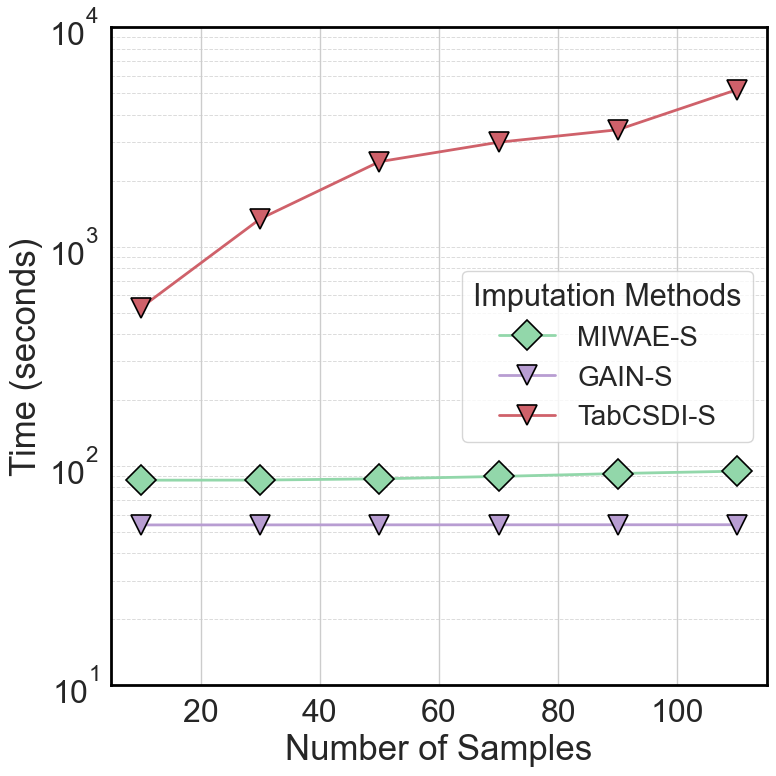

In [98]:
# Build a DataFrame from the user's table and plot Total time vs Samples (log-y) for all three algorithms.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

data = [
    ["GAIN-S",   10, 53.8252862, 0.0123959, 53.8376821],
    ["GAIN-S",   30, 53.8252862, 0.0343106, 53.8595968],
    ["GAIN-S",   50, 53.8252862, 0.0671938, 53.89248  ],
    ["GAIN-S",   70, 53.8252862, 0.0812605, 53.9065467],
    ["GAIN-S",   90, 53.8252862, 0.1075286, 53.9328148],
    ["GAIN-S",  110, 53.8252862, 0.1283992, 53.9536854],
    ["MIWAE-S",  10, 86.1222322, 1.0e-06,   86.1222332],
    ["MIWAE-S",  30, 86.1222322, 1.0e-06,   86.2222332],
    ["MIWAE-S",  50, 86.1222322, 1.2542499, 87.3764821],
    ["MIWAE-S",  70, 86.1222322, 3.462461,  89.5846932],
    ["MIWAE-S",  90, 86.1222322, 49.2406308,92.362863 ],
    ["MIWAE-S", 110, 86.1222322, 8.5634419, 94.6856741],
    ["TabCSDI-S",10, 0.0,        0.0,       527.8195485],
    ["TabCSDI-S",30, 0.0,        0.0,       1340.019997],
    ["TabCSDI-S",50, 0.0,        0.0,       2441.187241],
    ["TabCSDI-S",70, 0.0,        0.0,       2993.955257],
    ["TabCSDI-S",90, 0.0,        0.0,       3413.376712],
    ["TabCSDI-S",110,0.0,        0.0,       5202.505807],
]

df = pd.DataFrame(data, columns=["Algorithm","Sample","train_time_sec","sample_time_sec","total_time_sec"])

# Style
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15
plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
})

palette = {"MIWAE-S": "#92d7aa", "GAIN-S": "#b89dd2", "TabCSDI-S": "#CF616A"}
marker  = {"MIWAE-S": "D", "GAIN-S": "v", "TabCSDI-S": "v"}



# Combined plot (log-y)
plt.figure(figsize=(8,8))
for algo in ["MIWAE-S","GAIN-S","TabCSDI-S"]:
    sub = df[df["Algorithm"] == algo].sort_values("Sample")
    if sub.empty: 
        continue
    plt.plot(
        sub["Sample"].values, sub["total_time_sec"].values,
        marker=marker.get(algo, "o"), color=palette.get(algo, "black"),
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

plt.xlabel("Number of Samples", fontsize=x_label_fontsize)
plt.ylabel("Time (seconds)", fontsize=y_label_fontsize)

ax = plt.gca()
ax.set_yscale('log')
# Use fixed decade ticks 10^1..10^4 (covers 50s to ~5200s) 
ax.set_ylim(1e1, 1e4)
ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs='auto'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color('black'); spine.set_linewidth(2)
ax.yaxis.grid(True, which="both", linestyle='--', linewidth=0.7, alpha=0.7)

plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
plt.tight_layout()


pdf_log = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Wine_time_vs_samples_run1_logy.pdf"
plt.savefig(pdf_log, dpi=300, bbox_inches="tight")
plt.show()
